## Imports

In [7]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
file_list = [
    'shrid1_shrid2_key.csv',
    'shrid2_spatial_stats.csv',
    'shrid_loc_names.csv',
    'viirs_2023_7_5_500_ua_shrid2_key.csv'
]

for i in file_list:
    df_temp = pd.read_csv(i)
    print(f"--- File: {i} ---")
    print(f"Shape: {df_temp.shape}")
    print(f"Columns: {list(df_temp.columns)}")
    print("\n")

--- File: shrid1_shrid2_key.csv ---
Shape: (604218, 2)
Columns: ['shrid2', 'shrid1']


--- File: shrid2_spatial_stats.csv ---
Shape: (596358, 20)
Columns: ['shrid2', 'latitude', 'longitude', 'tdist_10_shrid', 'tdist_10', 'tdist_50_shrid', 'tdist_50', 'tdist_100_shrid', 'tdist_100', 'tdist_500_shrid', 'tdist_500', 'num_matched_pc11', 'num_matched_poly', 'num_final_poly', 'perim_dist_final_poly', 'shr_pop', 'thiessen_polygon', 'high_quality', 'polysource', 'area_laea']


--- File: shrid_loc_names.csv ---
Shape: (596389, 7)
Columns: ['shrid2', 'state_name', 'district_name', 'subdistrict_name', 'town_name', 'village_name', 'place_name']


--- File: viirs_2023_7_5_500_ua_shrid2_key.csv ---
Shape: (6334, 5)
Columns: ['index', 'shrid2', 'ua_id', 'ua_pc11_pca_tot_p', 'ua_pc11_land_area']




## Load Datas

In [10]:
df_spatial = pd.read_csv("shrid2_spatial_stats.csv")
df_loc = pd.read_csv("shrid_loc_names.csv")
df_viirs = pd.read_csv("viirs_2023_7_5_500_ua_shrid2_key.csv")

## SELECT IMPORTANT COLUMNS ONLY

##### SPATIAL DATASET

In [13]:
spatial_cols = [
    'shrid2',

    # Geographic coordinates
    'latitude',
    'longitude',

    # Connectivity features
    'tdist_10',
    'tdist_50',
    'tdist_100',
    'tdist_500',

    # Settlement features
    'shr_pop',
    'area_laea',

    # Data quality
    'high_quality'
]

df_spatial = df_spatial[spatial_cols]

#### LOCATION DATASET

In [15]:
loc_cols = [
    'shrid2',
    'state_name',
    'district_name',
    'subdistrict_name',
    'village_name'
]

df_loc = df_loc[loc_cols]

#### VIIRS DATASET

In [17]:
viirs_cols = [
    'shrid2',
    'ua_id',
    'ua_pc11_pca_tot_p',
    'ua_pc11_land_area'
]

df_viirs = df_viirs[viirs_cols]

# Data Merging: Dataset Integration

* **Consolidation:** The code performs a left join to combine spatial data with location (`df_loc`) and satellite-based luminosity data (`df_viirs`) using `shrid2` as the unique key.
* **Structural Alignment:** By using `how='left'`, the process ensures all records from the primary spatial dataframe are retained, enriching them with metadata and economic indicators.
* **Dataset Enrichment:** This integration bridges geographical coordinates with socioeconomic and nighttime light metrics, which are essential for calculating the final growth score.
* **Analytical Foundation:** Aligning these diverse data sources into a single, unified dataframe provides the necessary scope to perform multi-factor analysis across the entire study area.

In [19]:
df = df_spatial.copy()
df = pd.merge(
    df,
    df_loc,
    on='shrid2',
    how='left'
)


df = pd.merge(
    df,
    df_viirs,
    on='shrid2',
    how='left'
)


In [20]:
df.columns

Index(['shrid2', 'latitude', 'longitude', 'tdist_10', 'tdist_50', 'tdist_100',
       'tdist_500', 'shr_pop', 'area_laea', 'high_quality', 'state_name',
       'district_name', 'subdistrict_name', 'village_name', 'ua_id',
       'ua_pc11_pca_tot_p', 'ua_pc11_land_area'],
      dtype='object')

In [21]:
df.isnull().sum()

shrid2                    0
latitude                  0
longitude                 0
tdist_10                  0
tdist_50                  0
tdist_100                 0
tdist_500                 0
shr_pop                   0
area_laea                 0
high_quality              0
state_name                4
district_name             4
subdistrict_name        154
village_name           7668
ua_id                590024
ua_pc11_pca_tot_p    590024
ua_pc11_land_area    590024
dtype: int64

# Data Cleaning: Handling Missing Values

* **Integrity Filtering:** The `dropna` function removes rows with missing core identifiers, ensuring every record in the analysis has a valid location (State, District, Village).
* **Imputing Urban Data:** Setting missing `ua_cols` to zero assumes that areas with no recorded urban data lack significant urban influence, preventing calculation errors.
* **Standardizing Labels:** Filling empty `subdistrict_name` values with 'Unknown' preserves these rows for broader analysis while maintaining clear documentation of missing metadata.
* **Data Reliability:** These steps clean the dataset to ensure the `final_score` and spatial mappings are calculated using complete and consistent information.

In [23]:
df.dropna(subset=['state_name', 'district_name', 'village_name'], inplace=True)

ua_cols = ['ua_pc11_pca_tot_p', 'ua_pc11_land_area']
df[ua_cols] = df[ua_cols].fillna(0)

df['subdistrict_name'] = df['subdistrict_name'].fillna('Unknown')

In [24]:
df.shape

(588690, 17)

In [25]:
df.describe()

,latitude,longitude,tdist_10,tdist_50,tdist_100,tdist_500,shr_pop,area_laea,high_quality,ua_id,ua_pc11_pca_tot_p,ua_pc11_land_area
count,588690.000000,588690.000000,588690.000000,588690.000000,588690.000000,588690.000000,588690.000000,588690.000000,588690.000000,4322.000000,5.886900e+05,588690.000000
mean,23.647831,81.185363,12.559064,29.858616,43.055880,96.693234,0.000313,4.619757,0.999686,800292.607820,3.628170e+04,6.158508
std,4.731664,5.354856,11.059463,20.515701,29.801552,66.899199,0.017667,28.837968,0.017725,22038.096761,7.626889e+05,121.993402
min,6.764649,68.513270,0.000000,0.000000,0.000000,2.184323,0.000000,0.001090,0.000000,344458.000000,0.000000e+00,0.000000
25%,21.050401,76.919723,5.999361,15.905939,22.655690,54.118981,0.000000,1.092541,1.000000,800630.000000,0.000000e+00,0.000000
50%,24.415289,80.508771,10.107271,25.550827,36.132541,86.163360,0.000000,2.351115,1.000000,801357.000000,0.000000e+00,0.000000
75%,26.594481,84.963077,16.085153,38.520994,55.004380,123.518636,0.000000,5.011369,1.000000,802596.000000,0.000000e+00,0.000000
max,35.220498,97.234982,547.426159,554.580999,554.580999,1640.286296,1.000000,13765.888808,1.000000,803984.000000,2.459901e+07,7065.343830


#

# Data Preprocessing: Outlier Clipping

* **Goal:** The clipping process caps the extreme values in spatial distance columns (`tdist`) at the 95th percentile, effectively removing statistical noise.
* **Methodology:** By setting `upper=upper_limit`, any distance value beyond the 95th percentile is restricted, preventing outliers from skewing the model.
* **Result:** This ensures that remote or extreme data points do not disproportionately influence the `connectivity_score` calculation.
* **Integrity:** This approach maintains the relative variance of the majority of the data while ensuring a stable distribution for the scoring engine.

In [28]:
spatial_cols = ['tdist_10', 'tdist_50', 'tdist_100', 'tdist_500']

for col in spatial_cols:
    upper_limit = df[col].quantile(0.95)
    df[col] = df[col].clip(upper=upper_limit)

#

# Data Preprocessing: Log Transformation

* **Goal:** The logarithmic transformation `log1p(x)` (which computes $log(1+x)$) is used to handle skewed data by compressing large ranges and expanding small ones.
* **Impact on Variables:** It effectively normalizes the `ua_pc11_pca_tot_p` and `shr_pop` features, reducing the influence of extreme outliers.
* **Consistency:** This step ensures that features with vastly different scales become comparable, leading to a more robust `final_score` calculation.
* **Analytical Benefit:** By converting skewed distributions toward a normal distribution, the model becomes more sensitive to variations across the entire dataset.

In [31]:
df['ua_pc11_pca_tot_p_log'] = np.log1p(df['ua_pc11_pca_tot_p'])
df['shr_pop_log'] = np.log1p(df['shr_pop'])

In [32]:
df.describe()

,latitude,longitude,tdist_10,tdist_50,tdist_100,tdist_500,shr_pop,area_laea,high_quality,ua_id,ua_pc11_pca_tot_p,ua_pc11_land_area,ua_pc11_pca_tot_p_log,shr_pop_log
count,588690.000000,588690.000000,588690.000000,588690.000000,588690.000000,588690.000000,588690.000000,588690.000000,588690.000000,4322.000000,5.886900e+05,588690.000000,588690.000000,588690.000000
mean,23.647831,81.185363,11.956389,28.844177,41.666740,92.689777,0.000313,4.619757,0.999686,800292.607820,3.628170e+04,6.158508,0.102766,0.000217
std,4.731664,5.354856,7.742639,16.794546,25.214772,49.195594,0.017667,28.837968,0.017725,22038.096761,7.626889e+05,121.993402,1.205695,0.012253
min,6.764649,68.513270,0.000000,0.000000,0.000000,2.184323,0.000000,0.001090,0.000000,344458.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,21.050401,76.919723,5.999361,15.905939,22.655690,54.118981,0.000000,1.092541,1.000000,800630.000000,0.000000e+00,0.000000,0.000000,0.000000
50%,24.415289,80.508771,10.107271,25.550827,36.132541,86.163360,0.000000,2.351115,1.000000,801357.000000,0.000000e+00,0.000000,0.000000,0.000000
75%,26.594481,84.963077,16.085153,38.520994,55.004380,123.518636,0.000000,5.011369,1.000000,802596.000000,0.000000e+00,0.000000,0.000000,0.000000
max,35.220498,97.234982,30.589235,67.470299,102.071108,198.641991,1.000000,13765.888808,1.000000,803984.000000,2.459901e+07,7065.343830,17.018217,0.693147


#

# Feature Engineering: Scoring Model

* **Scoring Logic:** The `final_score` uses a weighted sum of three indicators, assigning 50% importance to connectivity, 30% to population density, and 20% to urban impact.
* **Connectivity (Infrastructure):** The formula $1 / (tdist_{10} + 1)$ uses inverse distance; as the distance to the nearest center decreases, the score increases, reflecting better accessibility.
* **Logarithmic Scaling:** Using `shr_pop_log` and `ua_pc11_pca_tot_p_log` compresses large values, ensuring that extreme data points do not bias the model and that relative differences are maintained.
* **Weighted Aggregation:** This approach allows for a balanced multi-dimensional assessment, where each variable contributes to a unified metric representing the growth potential of each village.

In [35]:
df['connectivity_score'] = 1 / (df['tdist_10'] + 1)

df['density_score'] = df['shr_pop_log']

df['urban_score'] = df['ua_pc11_pca_tot_p_log']

df['final_score'] = (df['connectivity_score'] * 0.5) + \
                    (df['density_score'] * 0.3) + \
                    (df['urban_score'] * 0.2)

# 3. Top 100 villages
top_100 = df.sort_values(by='final_score', ascending=False).head(100)

#  top 5 village
print(top_100[['village_name', 'state_name', 'final_score']].head())

                  village_name     state_name  final_score
107965              ilaichipur  uttar pradesh     3.903643
54947             morthal khas        haryana     3.903643
108067                piplehda  uttar pradesh     3.903643
107987  asalatpur farakh nagar  uttar pradesh     3.903643
108008             dasna dehat  uttar pradesh     3.903643


## HTML

In [37]:
# Create the map centered around the mean coordinates of your top 100
map_center = [top_100['latitude'].mean(), top_100['longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=6)

# Create a MarkerCluster to keep the map clean
marker_cluster = MarkerCluster().add_to(m)

# Add markers for each village in the top 100
# Marker pop-up update koro
for _, row in top_100.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=(
            f"<b>Village:</b> {row['village_name']}<br>"
            f"<b>Sub-District:</b> {row['subdistrict_name']}<br>"
            f"<b>District:</b> {row['district_name']}<br>"
            f"<b>State:</b> {row['state_name']}<br>"
            f"<b>Score:</b> {row['final_score']:.2f}"
        ),
        icon=folium.Icon(color='green', icon='info-sign')
    ).add_to(marker_cluster)

m.save('top_100_growing_villages.html')
print("Map saved as 'top_100_growing_villages.html'")

Map saved as 'top_100_growing_villages.html'


## Evalution

# Analysis of Final Economic Growth Score Distribution

The histogram illustrates the distribution of growth scores across the dataset. The key observations are as follows:

* **High Right-Skewness:** The distribution is heavily skewed to the right. A large majority of villages (over 95%) have a low growth score, concentrated near zero.
* **Power Law Pattern:** This pattern is consistent with economic data, where growth potential is not uniformly distributed but concentrated in a small fraction of the total population.
* **Identification of Growth Engines:** The long tail extending toward higher scores (0.5 to 4.0) represents the high-potential villages. The model successfully separates these outliers, which are the primary targets for economic development analysis.

# Conclusion for Reporting

The scoring model effectively filters significant growth centers from the vast majority of rural areas. This concentration suggests that targeted infrastructure and policy interventions in these high-scoring areas can yield disproportionately higher economic returns.

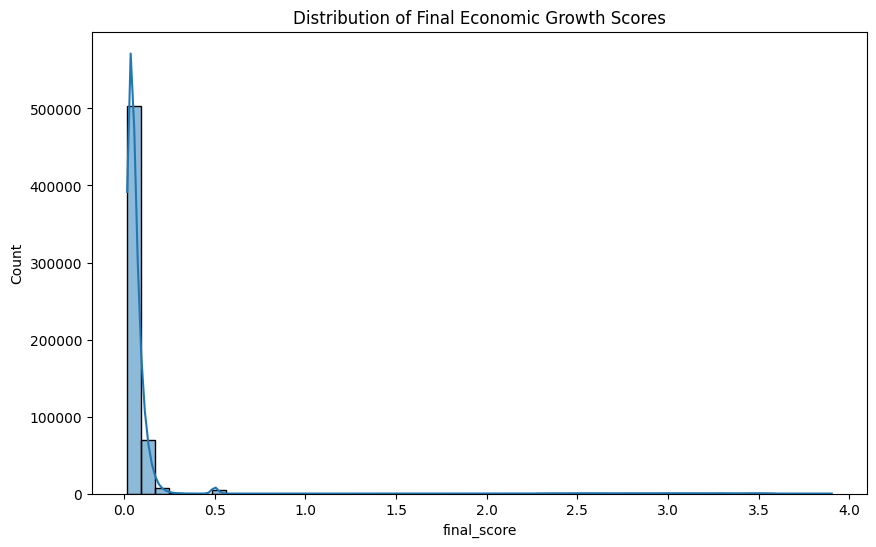

In [39]:
# Score
plt.figure(figsize=(10, 6))
sns.histplot(df['final_score'], kde=True, bins=50)
plt.title('Distribution of Final Economic Growth Scores')
plt.show()

# Analysis of Correlation Matrix

The correlation matrix measures the strength and direction of the linear relationship between the variables used in your scoring model. The key findings are as follows:

* **Urban Impact Dominance:** There is a strong positive correlation ($0.62$) between `ua_pc11_pca_tot_p` and `final_score`. This indicates that your model is highly sensitive to urban agglomeration, identifying it as the most significant driver of economic potential in your scoring system.
* **Connectivity Logic:** The negative correlation ($-0.21$) between `tdist_10` and `final_score` validates your methodology. Since `tdist_10` represents distance, a negative value confirms that as distance from urban centers increases, the growth score decreases, which matches the expected economic behavior.
* **Population Independence:** The low correlation ($0.01$) for `shr_pop` suggests that raw population size, in isolation, has minimal impact on the final score. This confirms that the model prioritizes structural and locational advantages over sheer population density.

In [41]:
# Correlation 
print(df[['final_score', 'tdist_10', 'shr_pop', 'ua_pc11_pca_tot_p']].corr())

                   final_score  tdist_10   shr_pop  ua_pc11_pca_tot_p
final_score           1.000000 -0.216411  0.012200           0.621847
tdist_10             -0.216411  1.000000  0.007199          -0.045808
shr_pop               0.012200  0.007199  1.000000          -0.000843
ua_pc11_pca_tot_p     0.621847 -0.045808 -0.000843           1.000000
